In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("amazon_reviews.csv")

df.head()

,Unnamed: 0,reviewerName,overall,reviewText,reviewTime,day_diff,helpful_yes,helpful_no,total_vote,score_pos_neg_diff,score_average_rating,wilson_lower_bound
0,0,NaN,4.0,No issues.,2014-07-23,138,0,0,0,0,0.0,0.0
1,1,0mie,5.0,"Purchased this for my device, it worked as adv...",2013-10-25,409,0,0,0,0,0.0,0.0
2,2,1K3,4.0,it works as expected. I should have sprung for...,2012-12-23,715,0,0,0,0,0.0,0.0
3,3,1m2,5.0,This think has worked out great.Had a diff. br...,2013-11-21,382,0,0,0,0,0.0,0.0
4,4,2&amp;1/2Men,5.0,"Bought it with Retail Packaging, arrived legit...",2013-07-13,513,0,0,0,0,0.0,0.0


In [3]:
print("Shape of dataset:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nMissing values:")
print(df.isnull().sum())

Shape of dataset: (4915, 12)

Columns:
Index(['Unnamed: 0', 'reviewerName', 'overall', 'reviewText', 'reviewTime',
       'day_diff', 'helpful_yes', 'helpful_no', 'total_vote',
       'score_pos_neg_diff', 'score_average_rating', 'wilson_lower_bound'],
      dtype='object')

Missing values:
Unnamed: 0              0
reviewerName            1
overall                 0
reviewText              1
reviewTime              0
day_diff                0
helpful_yes             0
helpful_no              0
total_vote              0
score_pos_neg_diff      0
score_average_rating    0
wilson_lower_bound      0
dtype: int64


In [4]:
print("Overall Rating Distribution:")
print(df["overall"].value_counts().sort_index())


Overall Rating Distribution:
overall
1.0     244
2.0      80
3.0     142
4.0     527
5.0    3922
Name: count, dtype: int64


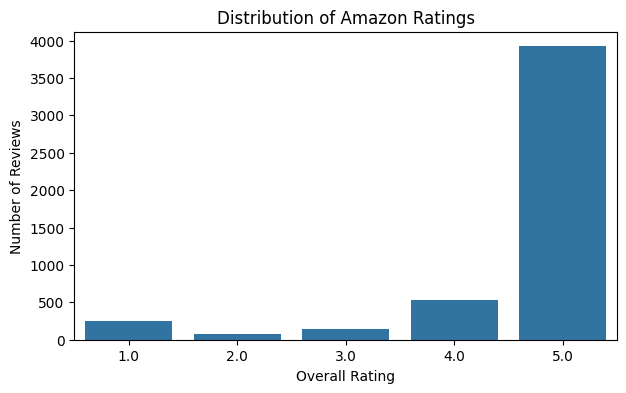

In [5]:
plt.figure(figsize=(7, 4))

sns.countplot(data=df, x="overall")

plt.title("Distribution of Amazon Ratings")
plt.xlabel("Overall Rating")
plt.ylabel("Number of Reviews")
plt.show()

In [6]:
df = df.dropna(subset=["reviewText"]).copy()

df["reviewText"] = df["reviewText"].astype(str).str.strip()

print("Dataset shape after cleaning:", df.shape)
print("Missing reviewText:", df["reviewText"].isnull().sum())

Dataset shape after cleaning: (4914, 12)
Missing reviewText: 0


In [7]:
def get_sentiment(rating):
    if rating <= 2:
        return "Negative"
    elif rating == 3:
        return "Neutral"
    else:
        return "Positive"

df["sentiment"] = df["overall"].apply(get_sentiment)

print(df[["overall", "sentiment"]].head(10))

   overall sentiment
0      4.0  Positive
1      5.0  Positive
2      4.0  Positive
3      5.0  Positive
4      5.0  Positive
5      5.0  Positive
6      5.0  Positive
7      5.0  Positive
8      5.0  Positive
9      5.0  Positive


In [8]:
print(df["sentiment"].value_counts())

sentiment
Positive    4448
Negative     324
Neutral      142
Name: count, dtype: int64


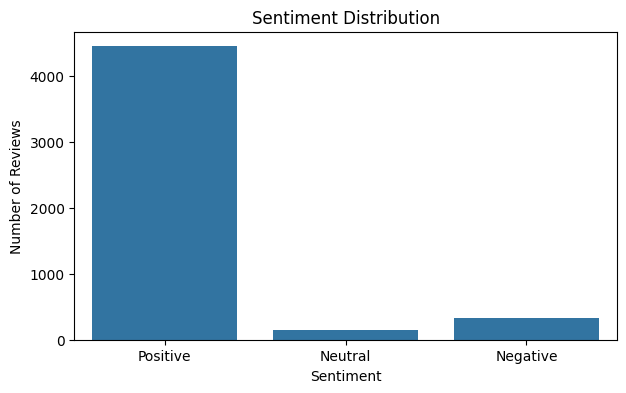

In [9]:
plt.figure(figsize=(7, 4))

sns.countplot(data=df, x="sentiment")

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()

In [10]:
df[["reviewText", "overall", "sentiment"]].head(10)

,reviewText,overall,sentiment
0,No issues.,4.0,Positive
1,"Purchased this for my device, it worked as adv...",5.0,Positive
2,it works as expected. I should have sprung for...,4.0,Positive
3,This think has worked out great.Had a diff. br...,5.0,Positive
4,"Bought it with Retail Packaging, arrived legit...",5.0,Positive
5,It's mini storage. It doesn't do anything els...,5.0,Positive
6,I have it in my phone and it never skips a bea...,5.0,Positive
7,It's hard to believe how affordable digital ha...,5.0,Positive
8,Works in a HTC Rezound. Was running short of ...,5.0,Positive
9,"in my galaxy s4, super fast card, and am total...",5.0,Positive


In [11]:
!pip install -q spacy
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 105.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [12]:
import spacy

nlp = spacy.load("en_core_web_sm")

In [13]:
def extract_aspects(text):
    doc = nlp(text)

    aspects = []

    for token in doc:
        if token.pos_ in ["NOUN", "PROPN"]:
            aspect = token.text.lower()

            if len(aspect) > 2 and aspect not in aspects:
                aspects.append(aspect)

    return aspects

In [14]:
sample_review = df["reviewText"].iloc[1]

print("Review:")
print(sample_review)

print("\nExtracted Aspects:")
print(extract_aspects(sample_review))

Review:
Purchased this for my device, it worked as advertised. You can never have too much phone memory, since I download a lot of stuff this was a no brainer for me.

Extracted Aspects:
['device', 'phone', 'memory', 'lot', 'stuff', 'brainer']


In [15]:
df["aspects"] = df["reviewText"].apply(extract_aspects)

df[["reviewText", "aspects"]].head(10)

,reviewText,aspects
0,No issues.,[issues]
1,"Purchased this for my device, it worked as adv...","[device, phone, memory, lot, stuff, brainer]"
2,it works as expected. I should have sprung for...,"[capacity, bit, versions, paint]"
3,This think has worked out great.Had a diff. br...,"[think, diff, bran, card, months, one, note3, ..."
4,"Bought it with Retail Packaging, arrived legit...","[retail, packaging, legit, orange, envelope, v..."
5,It's mini storage. It doesn't do anything els...,"[storage, microsoft, surface, pro, tablet, san..."
6,I have it in my phone and it never skips a bea...,"[phone, beat, file, transfers, corruption, iss..."
7,It's hard to believe how affordable digital ha...,"[digital, device, quarter, sie, postage, stamp..."
8,Works in a HTC Rezound. Was running short of ...,"[htc, rezound, space, sandisk, issues]"
9,"in my galaxy s4, super fast card, and am total...","[galaxy, card, words]"


In [16]:
print(df["aspects"].head(10).tolist())

[['issues'], ['device', 'phone', 'memory', 'lot', 'stuff', 'brainer'], ['capacity', 'bit', 'versions', 'paint'], ['think', 'diff', 'bran', 'card', 'months', 'one', 'note3', 'update', 'zero', 'issue', 'note2', 'solid!cheers'], ['retail', 'packaging', 'legit', 'orange', 'envelope', 'version', 'picture', 'shows', 'optimus', 'cards', 'order', 'price', 'card'], ['storage', 'microsoft', 'surface', 'pro', 'tablet', 'sandisk', 'reputation'], ['phone', 'beat', 'file', 'transfers', 'corruption', 'issues', 'memory', 'fade', 'sandisk', 'brand', 'card', 'files', 'piece', 'crap', 'couple', 'bucks', 'product'], ['digital', 'device', 'quarter', 'sie', 'postage', 'stamp', 'science', 'fiction', 'generation', 'music', 'schlep', 'risk', 'phone', 'ipod', 'works', 'card', 'readers', 'confidence'], ['htc', 'rezound', 'space', 'sandisk', 'issues'], ['galaxy', 'card', 'words']]


In [17]:
df_aspect = df[df["aspects"].apply(len) > 0].copy()

print("Reviews with extracted aspects:", len(df_aspect))

Reviews with extracted aspects: 4892


In [18]:
from transformers import pipeline

absa_model = pipeline(
    "text-classification",
    model="yangheng/deberta-v3-base-absa-v1.1"
)

config.json:   0%|          | 0.00/1.03k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  738MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/372 [00:00<?, ?B/s]

spm.model: reconstructing file:   0%|          |  0.00B / 2.46MB            

spm.model: downloading bytes:           |  0.00B            

added_tokens.json:   0%|          | 0.00/18.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

In [19]:
review = df_aspect["reviewText"].iloc[1]
aspect = df_aspect["aspects"].iloc[1][0]

print("Review:", review)
print("Aspect:", aspect)

result = absa_model(
    review,
    text_pair=aspect
)

print("\nABSA Result:")
print(result)

Review: Purchased this for my device, it worked as advertised. You can never have too much phone memory, since I download a lot of stuff this was a no brainer for me.
Aspect: device

ABSA Result:
[{'label': 'Neutral', 'score': 0.8761390447616577}]


In [20]:
def get_aspect_sentiment(review, aspect):
    result = absa_model(
        review,
        text_pair=aspect
    )[0]

    return result["label"], result["score"]

In [21]:
review = df_aspect["reviewText"].iloc[1]
aspects = df_aspect["aspects"].iloc[1]

results = []

for aspect in aspects:
    sentiment, confidence = get_aspect_sentiment(review, aspect)

    results.append({
        "aspect": aspect,
        "sentiment": sentiment,
        "confidence": confidence
    })

pd.DataFrame(results)

,aspect,sentiment,confidence
0,device,Neutral,0.876139
1,phone,Positive,0.911902
2,memory,Positive,0.978448
3,lot,Neutral,0.834051
4,stuff,Neutral,0.990818
5,brainer,Neutral,0.690681


In [22]:
from collections import Counter

aspect_counts = Counter(
    aspect
    for aspects in df_aspect["aspects"]
    for aspect in aspects
)

top_aspects = aspect_counts.most_common(15)

top_aspects

[('card', 2266),
 ('phone', 1146),
 ('memory', 1037),
 ('sandisk', 955),
 ('galaxy', 918),
 ('price', 791),
 ('samsung', 732),
 ('storage', 662),
 ('cards', 642),
 ('music', 525),
 ('tablet', 524),
 ('speed', 501),
 ('product', 469),
 ('problems', 441),
 ('camera', 441)]

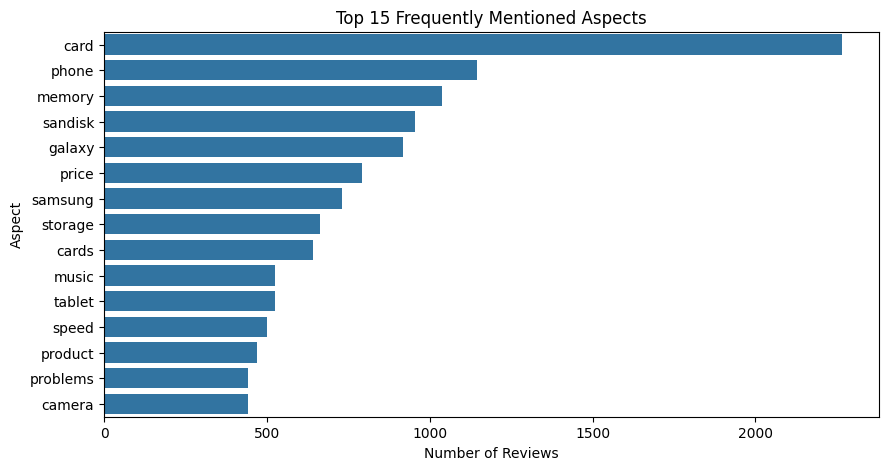

In [23]:
aspect_df = pd.DataFrame(top_aspects, columns=["aspect", "count"])

plt.figure(figsize=(10, 5))

sns.barplot(data=aspect_df, x="count", y="aspect")

plt.title("Top 15 Frequently Mentioned Aspects")
plt.xlabel("Number of Reviews")
plt.ylabel("Aspect")
plt.show()

In [25]:
top_aspect_names = [aspect for aspect, count in top_aspects]

print(top_aspect_names)

['card', 'phone', 'memory', 'sandisk', 'galaxy', 'price', 'samsung', 'storage', 'cards', 'music', 'tablet', 'speed', 'product', 'problems', 'camera']


In [37]:
# ABSA analysis on 1000 reviews containing top aspects

sample_df = df_aspect[
    df_aspect["aspects"].apply(
        lambda aspects: any(aspect in top_aspect_names for aspect in aspects)
    )
].head(1000).copy()

results = []

for _, row in sample_df.iterrows():
    review = row["reviewText"]

    for aspect in row["aspects"]:
        if aspect in top_aspect_names:
            sentiment, confidence = get_aspect_sentiment(review, aspect)

            results.append({
                "reviewText": review,
                "aspect": aspect,
                "sentiment": sentiment,
                "confidence": confidence
            })

absa_df = pd.DataFrame(results)

print("Reviews analyzed:", len(sample_df))
print("Total ABSA predictions:", len(absa_df))

Reviews analyzed: 1000
Total ABSA predictions: 2841


In [38]:
absa_df.head(10)

,reviewText,aspect,sentiment,confidence
0,"Purchased this for my device, it worked as adv...",phone,Positive,0.911902
1,"Purchased this for my device, it worked as adv...",memory,Positive,0.978448
2,This think has worked out great.Had a diff. br...,card,Positive,0.979313
3,"Bought it with Retail Packaging, arrived legit...",cards,Positive,0.867445
4,"Bought it with Retail Packaging, arrived legit...",price,Positive,0.882990
5,"Bought it with Retail Packaging, arrived legit...",card,Positive,0.853352
6,It's mini storage. It doesn't do anything els...,storage,Negative,0.913994
7,It's mini storage. It doesn't do anything els...,tablet,Neutral,0.988795
8,It's mini storage. It doesn't do anything els...,sandisk,Negative,0.627039
9,I have it in my phone and it never skips a bea...,phone,Neutral,0.982516


In [39]:
aspect_summary = (
    absa_df
    .groupby(["aspect", "sentiment"])
    .size()
    .reset_index(name="count")
)

aspect_summary

,aspect,sentiment,count
0,camera,Negative,7
1,camera,Neutral,66
2,camera,Positive,34
3,card,Negative,97
4,card,Neutral,113
5,card,Positive,315
6,cards,Negative,34
7,cards,Neutral,41
8,cards,Positive,82
9,galaxy,Negative,10


In [40]:
confidence_summary = (
    absa_df
    .groupby("aspect")["confidence"]
    .mean()
    .reset_index()
    .sort_values("confidence", ascending=False)
)

confidence_summary

,aspect,confidence
9,product,0.941247
7,price,0.929267
12,speed,0.905751
13,storage,0.891053
4,memory,0.880464
11,sandisk,0.873335
1,card,0.851228
14,tablet,0.846648
0,camera,0.843788
5,music,0.838755


In [41]:
print("PRODUCT REVIEW INTELLIGENCE SYSTEM")
print("=" * 45)

print("Total Reviews:", len(df))
print("Reviews with Extracted Aspects:", len(df_aspect))
print("Total Aspect-Level Predictions:", len(absa_df))

print("\nSentiment Distribution:")
print(absa_df["sentiment"].value_counts())

print("\nTop 5 Product Aspects:")
print(absa_df["aspect"].value_counts().head(5))

PRODUCT REVIEW INTELLIGENCE SYSTEM
Total Reviews: 4914
Reviews with Extracted Aspects: 4892
Total Aspect-Level Predictions: 2841

Sentiment Distribution:
sentiment
Positive    1516
Neutral      948
Negative     377
Name: count, dtype: int64

Top 5 Product Aspects:
aspect
card       525
phone      276
memory     235
sandisk    230
galaxy     216
Name: count, dtype: int64


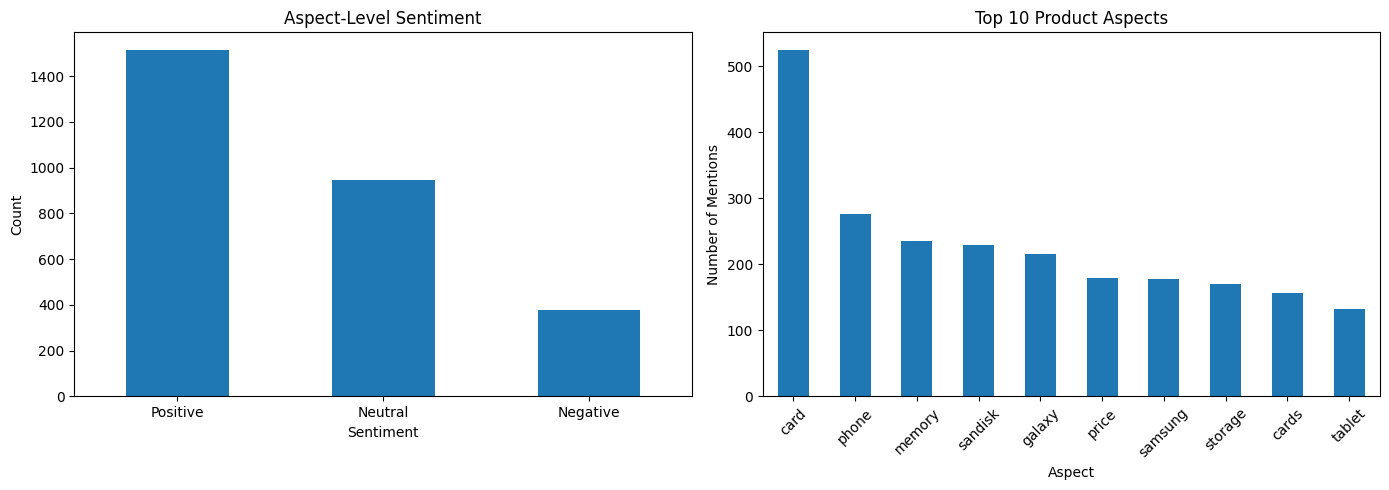

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sentiment distribution
absa_df["sentiment"].value_counts().plot(
    kind="bar",
    ax=axes[0]
)

axes[0].set_title("Aspect-Level Sentiment")
axes[0].set_xlabel("Sentiment")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=0)

# Top aspects
absa_df["aspect"].value_counts().head(10).plot(
    kind="bar",
    ax=axes[1]
)

axes[1].set_title("Top 10 Product Aspects")
axes[1].set_xlabel("Aspect")
axes[1].set_ylabel("Number of Mentions")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [43]:
final_results = (
    absa_df
    .groupby(["aspect", "sentiment"])
    .agg(
        mentions=("sentiment", "count"),
        average_confidence=("confidence", "mean")
    )
    .reset_index()
    .sort_values("mentions", ascending=False)
)

final_results.head(20)

,aspect,sentiment,mentions,average_confidence
5,card,Positive,315,0.881226
23,price,Positive,169,0.944565
19,phone,Neutral,169,0.875632
35,sandisk,Positive,165,0.918516
10,galaxy,Neutral,146,0.827488
41,storage,Positive,122,0.907276
14,memory,Positive,120,0.875806
4,card,Neutral,113,0.790725
3,card,Negative,97,0.824296
43,tablet,Neutral,93,0.884724


In [44]:
print("""
CONCLUSION

The Product Review Intelligence System analyzes Amazon customer reviews
using sentiment analysis and aspect-based sentiment analysis.

The system extracts important product aspects from reviews and determines
the sentiment associated with each aspect along with its confidence score.

This helps identify which product features customers view positively,
negatively, or neutrally and provides useful insights from customer feedback.
""")


CONCLUSION

The Product Review Intelligence System analyzes Amazon customer reviews
using sentiment analysis and aspect-based sentiment analysis.

The system extracts important product aspects from reviews and determines
the sentiment associated with each aspect along with its confidence score.

This helps identify which product features customers view positively,
negatively, or neutrally and provides useful insights from customer feedback.

